In [1]:
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from scipy.stats import ks_2samp

In [2]:
PARQUET_FILES = [
    r"C:\Users\hp\OneDrive\Desktop\interview\QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet",
    r"C:\Users\hp\OneDrive\Desktop\interview\QCDToGGQQ_IMGjet_RH1all_jet0_run1_n47540_LR.parquet",
    r"C:\Users\hp\OneDrive\Desktop\interview\QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494_LR.parquet",
]
DATASET_LABELS = ['Dataset-1 (Train)', 'Dataset-2 (Val)', 'Dataset-3 (Test)']
MAX_ROWS   = 50
UPSCALE    = 2
CH_LABELS  = ['ECAL', 'HCAL', 'Tracks']

def extract_image(val):
    return np.array([np.array(row, dtype=np.float32) for row in val], dtype=np.float32)

def extract_jet(val):
    return np.stack([extract_image(ch) for ch in val])  # (3, H, W)

def load_lr_images(parquet_file, image_col='X_jets_LR', max_rows=MAX_ROWS):
    images = []
    for batch in pq.ParquetFile(parquet_file).iter_batches(batch_size=25):
        df = batch.to_pandas()
        for val in df[image_col].values:
            images.append(extract_jet(val))
            if len(images) >= max_rows:
                break
        if len(images) >= max_rows:
            break
    return np.stack(images)  # (N, 3, H, W)

def upsample_nearest(x, scale=UPSCALE):
    return zoom(x, (1, 1, scale, scale), order=0)

def upsample_bicubic(x, scale=UPSCALE):
    return zoom(x, (1, 1, scale, scale), order=3)

print("Loading datasets...")
lr_runs = [load_lr_images(p) for p in PARQUET_FILES]
for i, imgs in enumerate(lr_runs):
    print(f"  {DATASET_LABELS[i]}: {imgs.shape}")

Loading datasets...
  Dataset-1 (Train): (50, 3, 64, 64)
  Dataset-2 (Val): (50, 3, 64, 64)
  Dataset-3 (Test): (50, 3, 64, 64)


In [3]:
baselines = []
for imgs in lr_runs:
    baselines.append({
        "lr":      imgs,
        "nearest": upsample_nearest(imgs),
        "bicubic": upsample_bicubic(imgs),
    })

print("Baselines built:")
for k, v in baselines[0].items():
    print(f"  {k}: {v.shape}")

Baselines built:
  lr: (50, 3, 64, 64)
  nearest: (50, 3, 128, 128)
  bicubic: (50, 3, 128, 128)


In [4]:
def mean_pixel_energy(imgs):
    """(N, C, H, W) → (N,) mean energy per pixel per jet."""
    return imgs.mean(axis=(1, 2, 3))

def energy_conservation_error(lr, upsampled):
    """Fractional error: |E_up - E_lr| / |E_lr| per jet."""
    e_lr = mean_pixel_energy(lr)
    e_up = mean_pixel_energy(upsampled)
    return np.abs(e_up - e_lr) / (np.abs(e_lr) + 1e-8)

print("METRIC 1 — ENERGY CONSERVATION ERROR")
print("-" * 60)
for i, data in enumerate(baselines):
    err_nn = energy_conservation_error(data["lr"], data["nearest"])
    err_bc = energy_conservation_error(data["lr"], data["bicubic"])
    print(f"\n{DATASET_LABELS[i]}")
    print(f"  Nearest : {np.mean(err_nn)*100:.4f}%  (std {np.std(err_nn)*100:.4f}%)")
    print(f"  Bicubic : {np.mean(err_bc)*100:.4f}%  (std {np.std(err_bc)*100:.4f}%)")

METRIC 1 — ENERGY CONSERVATION ERROR
------------------------------------------------------------

Dataset-1 (Train)
  Nearest : 0.0000%  (std 0.0000%)
  Bicubic : 1.4767%  (std 0.1208%)

Dataset-2 (Val)
  Nearest : 0.0000%  (std 0.0000%)
  Bicubic : 1.5017%  (std 0.0940%)

Dataset-3 (Test)
  Nearest : 0.0000%  (std 0.0000%)
  Bicubic : 1.4509%  (std 0.2160%)


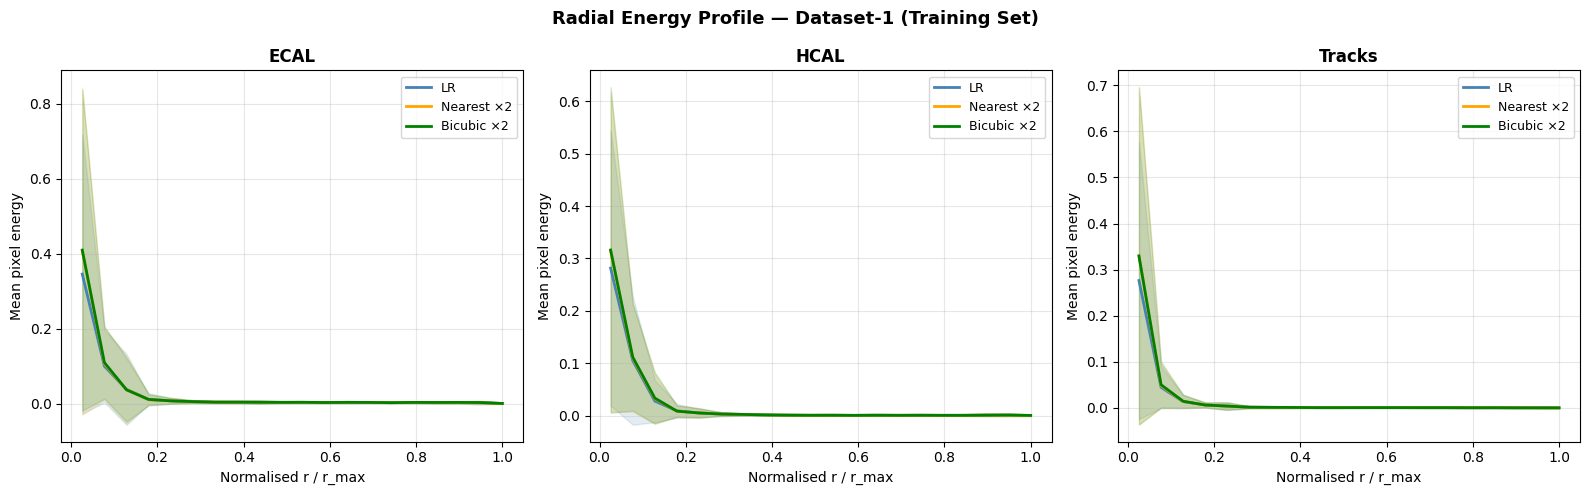

In [5]:
def radial_profile(image, n_bins=20):
    H, W   = image.shape
    cy, cx = H / 2.0, W / 2.0
    yi, xi = np.indices((H, W))
    r      = np.sqrt((xi - cx)**2 + (yi - cy)**2)
    r_max  = np.sqrt(cx**2 + cy**2)
    bins   = np.linspace(0, r_max, n_bins + 1)
    centres = 0.5 * (bins[:-1] + bins[1:])
    profile = np.array([
        image[(r >= bins[b]) & (r < bins[b+1])].mean()
        if np.any((r >= bins[b]) & (r < bins[b+1])) else 0.0
        for b in range(n_bins)
    ])
    return centres, profile

def mean_radial_profile(imgs, channel=0, n_bins=20):
    profiles = np.stack([radial_profile(imgs[n, channel], n_bins)[1]
                         for n in range(len(imgs))])
    centres  = radial_profile(imgs[0, channel], n_bins)[0]
    return centres, profiles.mean(axis=0), profiles.std(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Radial Energy Profile — Dataset-1 (Training Set)', fontweight='bold', fontsize=13)

data = baselines[0]
method_styles = [
    ("lr",      "steelblue", "LR"),
    ("nearest", "orange",    f"Nearest ×{UPSCALE}"),
    ("bicubic", "green",     f"Bicubic ×{UPSCALE}"),
]

for c, (ax, ch) in enumerate(zip(axes, CH_LABELS)):
    for key, color, label in method_styles:
        r, mu, sigma = mean_radial_profile(data[key], channel=c)
        r_norm = r / r.max()
        ax.plot(r_norm, mu, label=label, color=color, lw=2)
        ax.fill_between(r_norm, mu - sigma, mu + sigma, alpha=0.15, color=color)
    ax.set_title(ch, fontweight='bold')
    ax.set_xlabel('Normalised r / r_max')
    ax.set_ylabel('Mean pixel energy')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

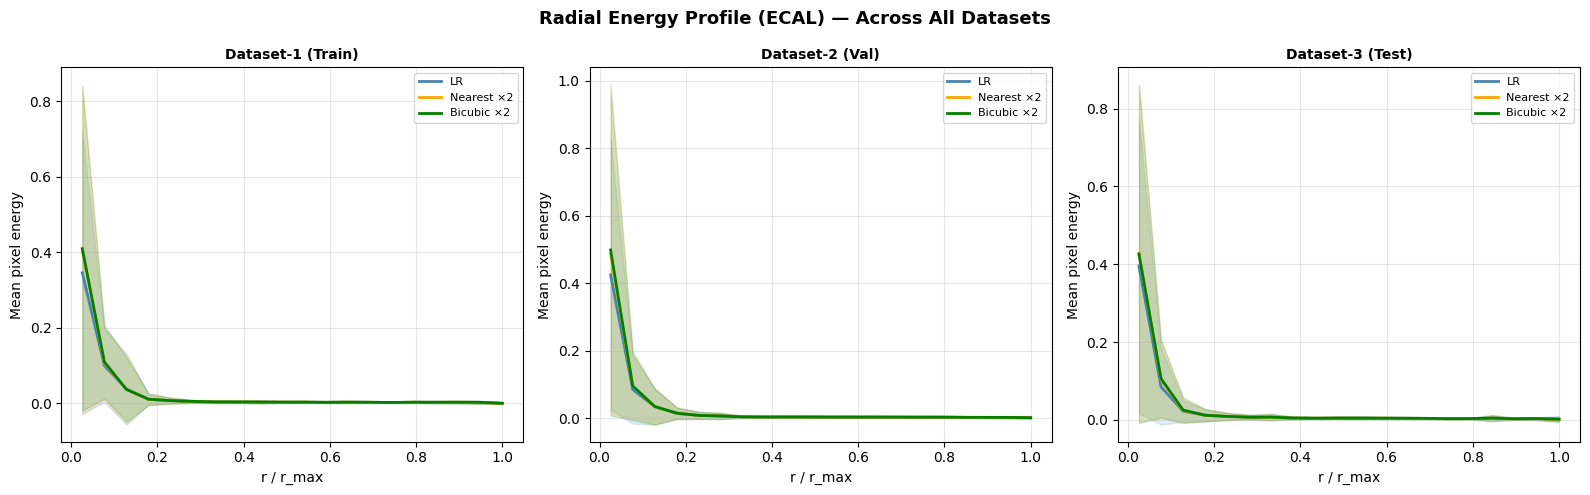

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Radial Energy Profile (ECAL) — Across All Datasets',
             fontweight='bold', fontsize=13)

for ax, data, dlabel in zip(axes, baselines, DATASET_LABELS):
    for key, color, mlabel in method_styles:
        r, mu, sigma = mean_radial_profile(data[key], channel=0)
        r_norm = r / r.max()
        ax.plot(r_norm, mu, label=mlabel, color=color, lw=2)
        ax.fill_between(r_norm, mu - sigma, mu + sigma, alpha=0.15, color=color)
    ax.set_title(dlabel, fontweight='bold', fontsize=10)
    ax.set_xlabel('r / r_max')
    ax.set_ylabel('Mean pixel energy')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
def mae(lr, upsampled):
    lr_from_up = zoom(upsampled, (1, 1, 1/UPSCALE, 1/UPSCALE), order=1)
    return np.abs(lr - lr_from_up).mean(axis=(1, 2, 3))

def psnr(lr, upsampled):
    lr_from_up = zoom(upsampled, (1, 1, 1/UPSCALE, 1/UPSCALE), order=1)
    mse = ((lr - lr_from_up)**2).mean(axis=(1, 2, 3))
    max_val = lr.max()
    return 10 * np.log10(max_val**2 / (mse + 1e-8))

print("METRIC 3 — PIXEL-WISE MAE & PSNR (downsample-back comparison)")
print("-" * 60)
for i, data in enumerate(baselines):
    print(f"\n{DATASET_LABELS[i]}")
    print(f"  MAE  — Nearest: {mae(data['lr'], data['nearest']).mean():.6f}  "
          f"Bicubic: {mae(data['lr'], data['bicubic']).mean():.6f}")
    print(f"  PSNR — Nearest: {psnr(data['lr'], data['nearest']).mean():.2f} dB  "
          f"Bicubic: {psnr(data['lr'], data['bicubic']).mean():.2f} dB")

METRIC 3 — PIXEL-WISE MAE & PSNR (downsample-back comparison)
------------------------------------------------------------

Dataset-1 (Train)
  MAE  — Nearest: 0.000000  Bicubic: 0.001541
  PSNR — Nearest: 113.16 dB  Bicubic: 66.15 dB

Dataset-2 (Val)
  MAE  — Nearest: 0.000000  Bicubic: 0.001665
  PSNR — Nearest: 112.88 dB  Bicubic: 65.07 dB

Dataset-3 (Test)
  MAE  — Nearest: 0.000000  Bicubic: 0.001740
  PSNR — Nearest: 107.53 dB  Bicubic: 60.04 dB


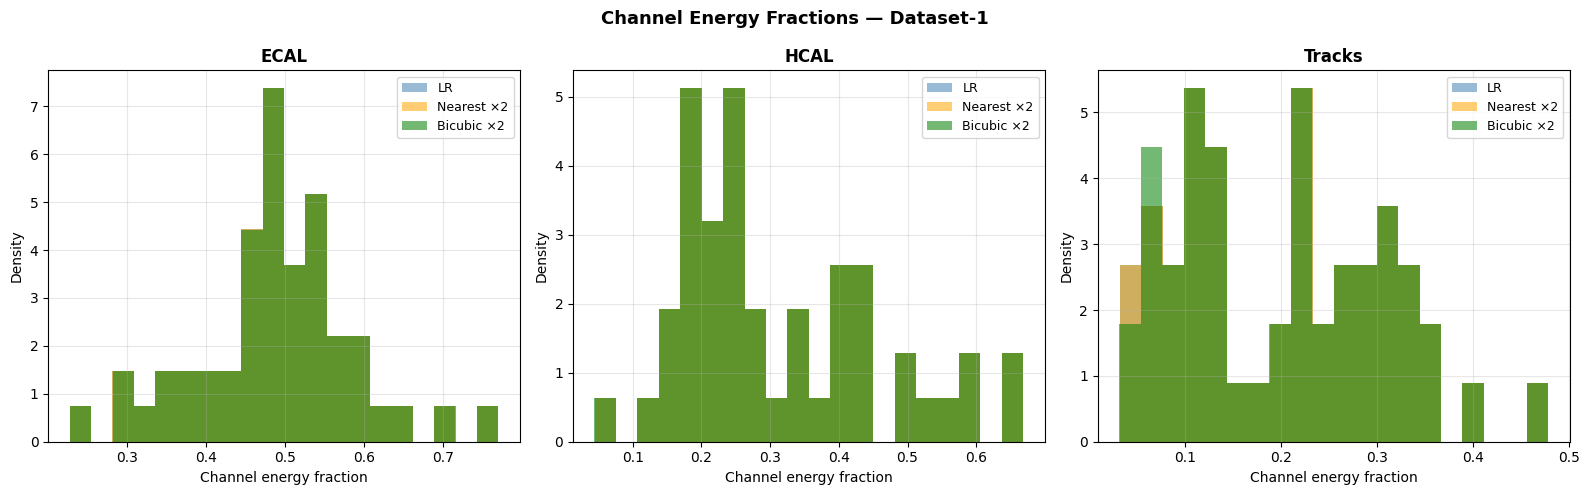

In [8]:
def channel_fractions(imgs):
    ch_e  = imgs.sum(axis=(2, 3))
    total = ch_e.sum(axis=1, keepdims=True)
    return ch_e / np.where(total == 0, 1, total)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Channel Energy Fractions — Dataset-1',
             fontweight='bold', fontsize=13)

data   = baselines[0]
colors = ['steelblue', 'orange', 'green']

for c, (ax, ch) in enumerate(zip(axes, CH_LABELS)):
    for (key, klabel), color in zip([("lr","LR"),
                                     ("nearest",f"Nearest ×{UPSCALE}"),
                                     ("bicubic",f"Bicubic ×{UPSCALE}")], colors):
        ax.hist(channel_fractions(data[key])[:, c],
                bins=20, alpha=0.55, density=True, color=color, label=klabel)
    ax.set_title(ch, fontweight='bold')
    ax.set_xlabel('Channel energy fraction')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
print("METRIC 5 — KS GENERALIZATION TEST (total jet energy, LR)")
print("-" * 60)

energies = [baselines[i]["lr"].sum(axis=(1, 2, 3)) for i in range(3)]
pairs    = [(0, 1, "D1 vs D2"), (0, 2, "D1 vs D3"), (1, 2, "D2 vs D3")]

for a, b, label in pairs:
    ks, p  = ks_2samp(energies[a], energies[b])
    status = "PASS" if p > 0.05 else "FAIL"
    print(f"  {label}: KS={ks:.4f}  p={p:.4f}  [{status}]")

METRIC 5 — KS GENERALIZATION TEST (total jet energy, LR)
------------------------------------------------------------
  D1 vs D2: KS=0.2200  p=0.1786  [PASS]
  D1 vs D3: KS=0.2800  p=0.0392  [FAIL]
  D2 vs D3: KS=0.1400  p=0.7166  [PASS]


In [10]:
print("\n" + "=" * 65)
print("PHYSICS METRICS SUMMARY — 03_physics_metrics.ipynb")
print("=" * 65)
print(f"{'Metric':<32} {'Nearest':>14} {'Bicubic':>14}")
print("-" * 65)

for i, data in enumerate(baselines):
    print(f"\n{DATASET_LABELS[i]}")
    e_nn  = energy_conservation_error(data["lr"], data["nearest"]).mean() * 100
    e_bc  = energy_conservation_error(data["lr"], data["bicubic"]).mean() * 100
    m_nn  = mae(data["lr"],  data["nearest"]).mean()
    m_bc  = mae(data["lr"],  data["bicubic"]).mean()
    p_nn  = psnr(data["lr"], data["nearest"]).mean()
    p_bc  = psnr(data["lr"], data["bicubic"]).mean()
    print(f"  {'Energy Conservation Err (%)':<30} {e_nn:>14.4f} {e_bc:>14.4f}")
    print(f"  {'MAE (pixel)':<30} {m_nn:>14.6f} {m_bc:>14.6f}")
    print(f"  {'PSNR (dB)':<30} {p_nn:>14.2f} {p_bc:>14.2f}")

print("\n" + "=" * 65)
print("Next step: replace baselines with GAN output and rerun metrics.")
print("=" * 65)


PHYSICS METRICS SUMMARY — 03_physics_metrics.ipynb
Metric                                  Nearest        Bicubic
-----------------------------------------------------------------

Dataset-1 (Train)
  Energy Conservation Err (%)            0.0000         1.4767
  MAE (pixel)                          0.000000       0.001541
  PSNR (dB)                              113.16          66.15

Dataset-2 (Val)
  Energy Conservation Err (%)            0.0000         1.5017
  MAE (pixel)                          0.000000       0.001665
  PSNR (dB)                              112.88          65.07

Dataset-3 (Test)
  Energy Conservation Err (%)            0.0000         1.4509
  MAE (pixel)                          0.000000       0.001740
  PSNR (dB)                              107.53          60.04

Next step: replace baselines with GAN output and rerun metrics.
